# Part 1 - Deep Networks

Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N = 3000 # size of dataset
x1 = np.random.uniform(-2, 2, N)
x2 = np.random.uniform(-2, 2, N)

X = np.column_stack((x1, x2))
y = np.where((x1**2 + x2**2) > 1.5, 1, 0).reshape(-1, 1)

Split the dataset

In [2]:
indices = np.random.permutation(N)

train_size = int(0.70*N)
val_size = int(0.15*N)

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size+val_size]
test_idx = indices[train_size + val_size:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"Training: {X_train.shape}, {y_train.shape}")
print(f"Validation: {X_val.shape}, {y_val.shape}")
print(f"Test: {X_test.shape}, {y_test.shape}")

Training: (2100, 2), (2100, 1)
Validation: (450, 2), (450, 1)
Test: (450, 2), (450, 1)


Task 1A - Build 3 Architectures

In [23]:
class DenseLayer:
    def __init__(self, n_in, n_out):
        self.n_in = n_in
        self.n_out = n_out
        self.W = np.random.randn(n_in, n_out) * np.sqrt(2. / n_in)
        self.b = np.zeros((1, n_out))
        self.dW = None
        self.db = None
        self.inputs = None
        
    def forward(self, X):
        self.inputs = X
        return np.dot(X, self.W) + self.b
    
    def backward(self, dZ):
        self.dW = np.dot(self.inputs.T, dZ)
        self.db = np.sum(dZ, axis=0, keepdims=True)
        
        dX = np.dot(dZ, self.W.T)
        return dX
    
    def count_params(self):
        return (self.n_in * self.n_out) + self.n_out

In [25]:
class SequentialModel:
    def __init__(self):
        self.layers = []
        
    def add(self, layer):
        self.layers.append(layer)
        
    def forward(self, X):
        # Pass the output of one layer as the input to the next
        A = X
        for layer in self.layers:
            A = layer.forward(A)
        return A
        
    def backward(self, dA):
        # Backpropagate the gradient in reverse order
        for layer in reversed(self.layers):
            dA = layer.backward(dA)
        return dA

In [26]:
class ReLU:
    def __init__(self):
        self.Z = None

    def forward(self, z):
        self.Z = z
        return np.maximum(0, z)

    def backward(self, dA):
        dZ = dA.copy()
        dZ[self.Z <= 0] = 0
        return dZ


class Sigmoid:
    def __init__(self):
        self.A = None

    def forward(self, z):
        self.A = 1 / (1 + np.exp(-z))
        return self.A

    def backward(self, dA):
        dZ = dA * self.A * (1 - self.A)
        return dZ

In [27]:
def get_activation_layer(activation_name):
    if activation_name.lower() == 'relu':
        return ReLU()
    elif activation_name.lower() == 'sigmoid':
        return Sigmoid()

# 1. Build the 2-Layer Network
def build_2_layer_model(input_dim=2, hidden_dim=4, activation='relu'):
    model = SequentialModel()
    # Hidden Layer 1
    model.add(DenseLayer(input_dim, hidden_dim))
    model.add(get_activation_layer(activation))
    
    # Output Layer
    model.add(DenseLayer(hidden_dim, 1))
    model.add(Sigmoid()) # 1 output neuron (sigmoid)
    return model

# 2. Build the 5-Layer Network
def build_5_layer_model(input_dim=2, hidden_dim=4, activation='relu'):
    model = SequentialModel()
    # Hidden Layer 1 (Input)
    model.add(DenseLayer(input_dim, hidden_dim))
    model.add(get_activation_layer(activation))
    
    # Hidden Layers 2, 3, 4
    for _ in range(3):
        model.add(DenseLayer(hidden_dim, hidden_dim))
        model.add(get_activation_layer(activation))
        
    # Output Layer (Layer 5)
    model.add(DenseLayer(hidden_dim, 1))
    model.add(Sigmoid())
    return model

# 3. Build the 10-Layer Network
def build_10_layer_model(input_dim=2, hidden_dim=4, activation='relu'):
    model = SequentialModel()
    # Hidden Layer 1 (Input)
    model.add(DenseLayer(input_dim, hidden_dim))
    model.add(get_activation_layer(activation))
    
    # Hidden Layers 2 through 9
    for _ in range(8):
        model.add(DenseLayer(hidden_dim, hidden_dim))
        model.add(get_activation_layer(activation))
        
    # Output Layer (Layer 10)
    model.add(DenseLayer(hidden_dim, 1))
    model.add(Sigmoid())
    return model

In [28]:
# models with relu
model_2L_relu = build_2_layer_model(activation='relu')
model_5L_relu = build_5_layer_model(activation='relu')
model_10L_relu = build_10_layer_model(activation='relu')

# models with sigmoid 
model_2L_sig = build_2_layer_model(activation='sigmoid')
model_5L_sig = build_5_layer_model(activation='sigmoid')
model_10L_sig = build_10_layer_model(activation='sigmoid')

TASK 1B - Param Calculation

1. 2-Layer Network
    * Hidden Layer 1: 2 inputs ($x_1, x_2$), 4 output neurons.
        - Parameters = $(2 \times 4) + 4 = 12$
    * Output Layer: 4 inputs (from hidden layer), 1 output neuron.
        - Parameters = $(4 \times 1) + 1 = 5$
    * Total Parameters: $12 + 5 = 17$

2. 5-Layer Network
    * Hidden Layer 1: 2 inputs, 4 neurons $\rightarrow$ $(2 \times 4) + 4 = 12$
    * Hidden Layer 2: 4 inputs, 4 neurons $\rightarrow$ $(4 \times 4) + 4 = 20$
    * Hidden Layer 3: 4 inputs, 4 neurons $\rightarrow$ $(4 \times 4) + 4 = 20$
    * Hidden Layer 4: 4 inputs, 4 neurons $\rightarrow$ $(4 \times 4) + 4 = 20$
    * Output Layer: 4 inputs, 1 neuron $\rightarrow$ $(4 \times 1) + 1 = 5$
    * Total Parameters: $12 + 20 + 20 + 20 + 5 = 77$

3. 10-Layer Network
    * Hidden Layer 1: 2 inputs, 4 neurons $\rightarrow$ $(2 \times 4) + 4 = 12$
    * Hidden Layers 2 through 9 (8 layers): Each has 4 inputs, 4 neurons.
        * Parameters per layer = $(4 \times 4) + 4 = 20$
        * Total for these 8 layers = $8 \times 20 = 160$
    * Output Layer: 4 inputs, 1 neuron $\rightarrow$ $(4 \times 1) + 1 = 5$
    * Total Parameters: $12 + 160 + 5 = 177$

Task 1C - Optimizer Comparison

In [53]:
class BCELoss:
    def __init__(self):
        self.epsilon = 1e-8
        
    def forward(self, y_pred, y_true):
        m = y_true.shape[0]
        loss = - (1/m) * np.sum(y_true * np.log(y_pred + self.epsilon) + (1 - y_true) * np.log(1 - y_pred + self.epsilon))
        return loss

    def backward(self, y_pred, y_true):
        m = y_true.shape[0]
        dA = - (np.divide(y_true, y_pred) - np.divide(1 - y_true, 1 - y_pred)) / m
        return dA

In [54]:
class Optimizer:
    def __init__(self, model, lr=0.01, opt_type='sgd', beta=0.9):
        self.model = model
        self.lr = lr
        self.opt_type = opt_type.lower()
        self.beta = beta
        
        if self.opt_type == 'momentum':
            for layer in self.model.layers:
                if hasattr(layer, 'W'):
                    layer.v_W = np.zeros_like(layer.W)
                    layer.v_b = np.zeros_like(layer.b)
                    
    def step(self):
        for layer in self.model.layers:
            if hasattr(layer, 'W'):
                if self.opt_type == 'sgd':
                    layer.W -= self.lr * layer.dW
                    layer.b -= self.lr * layer.db
                    
                elif self.opt_type == 'momentum':
                    layer.v_W = self.beta * layer.v_W + self.lr * layer.dW
                    layer.v_b = self.beta * layer.v_b + self.lr * layer.db
                    
                    layer.W -= layer.v_W
                    layer.b -= layer.v_b

In [55]:
def calculate_accuracy(y_pred, y_true):
    y_pred_bin = (y_pred >= 0.5).astype(int)
    return np.mean(y_pred_bin == y_true)

def get_gradient_norms(model):
    norms = []
    for layer in model.layers:
        if hasattr(layer, 'dW'):
            norm = np.sqrt(np.sum(layer.dW ** 2))
            norms.append(norm)
    return norms

def train_model(model, X_train, y_train, X_val, y_val, epochs=500, lr=0.05, opt_type='sgd'):
    criterion = BCELoss()
    optimizer = Optimizer(model, lr=lr, opt_type=opt_type)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'grad_norms': []}
    
    for epoch in range(epochs):
        train_pred = model.forward(X_train)
        train_loss = criterion.forward(train_pred, y_train)
        train_acc = calculate_accuracy(train_pred, y_train)
        
        dA = criterion.backward(train_pred, y_train)
        model.backward(dA)
        history['grad_norms'].append(get_gradient_norms(model))
        optimizer.step()
        
        val_pred = model.forward(X_val)
        val_loss = criterion.forward(val_pred, y_val)
        val_acc = calculate_accuracy(val_pred, y_val)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
            
    return history

In [56]:
def evaluate_model(model, X, Y):
    criterion = BCELoss()
    pred = model.forward(X)
    loss = criterion.forward(pred, Y)
    acc = calculate_accuracy(pred, Y)
    return loss, acc

architectures = {
    "2-Layer": build_2_layer_model,
    "5-Layer": build_5_layer_model,
    "10-Layer": build_10_layer_model
}
activations = ["relu", "sigmoid"]
optimizers = ["sgd", "momentum"]

all_histories = {}

print(f"{'Model':<10} | {'Act':<7} | {'Opt':<8} | {'Train Acc':<9} | {'Val Acc':<7} | {'Test Acc':<8} | {'Train Loss':<10} | {'Val Loss':<8} | {'Test Loss'}")
print("-" * 105)

# Loop through all 12 combinations
for arch_name, build_fn in architectures.items():
    for act in activations:
        for opt in optimizers:
            exp_name = f"{arch_name}_{act}_{opt}"
            
            model = build_fn(activation=act)
            
            # Train
            history = train_model(model, X_train, y_train, X_val, y_val, epochs=800, lr=0.05, opt_type=opt)
            all_histories[exp_name] = history
            
            # Test
            test_loss, test_acc = evaluate_model(model, X_test, y_test)
            
            # final epoch metrics
            t_acc, v_acc = history['train_acc'][-1], history['val_acc'][-1]
            t_loss, v_loss = history['train_loss'][-1], history['val_loss'][-1]
            
            print(f"{arch_name:<10} | {act:<7} | {opt:<8} | {t_acc:<9.4f} | {v_acc:<7.4f} | {test_acc:<8.4f} | {t_loss:<10.4f} | {v_loss:<8.4f} | {test_loss:.4f}")

Model      | Act     | Opt      | Train Acc | Val Acc | Test Acc | Train Loss | Val Loss | Test Loss
---------------------------------------------------------------------------------------------------------
2-Layer    | relu    | sgd      | 0.9238    | 0.9400  | 0.9200   | 0.2923     | 0.2746   | 0.3058
2-Layer    | relu    | momentum | 0.9857    | 0.9844  | 0.9911   | 0.0736     | 0.0688   | 0.0689
2-Layer    | sigmoid | sgd      | 0.7043    | 0.7489  | 0.7400   | 0.6082     | 0.5707   | 0.5771
2-Layer    | sigmoid | momentum | 0.9195    | 0.9511  | 0.9244   | 0.2820     | 0.2579   | 0.2728
5-Layer    | relu    | sgd      | 0.7043    | 0.7489  | 0.7400   | 0.5683     | 0.5196   | 0.5467


C:\Users\vansh\AppData\Local\Temp\ipykernel_11992\2259855148.py:12: RuntimeWarning: invalid value encountered in divide
  dA = - (np.divide(y_true, y_pred) - np.divide(1 - y_true, 1 - y_pred)) / m


5-Layer    | relu    | momentum | 0.2957    | 0.2511  | 0.2600   | nan        | nan      | nan
5-Layer    | sigmoid | sgd      | 0.7043    | 0.7489  | 0.7400   | 0.6071     | 0.5684   | 0.5762
5-Layer    | sigmoid | momentum | 0.7043    | 0.7489  | 0.7400   | 0.6072     | 0.5685   | 0.5761
10-Layer   | relu    | sgd      | 0.7043    | 0.7489  | 0.7400   | 0.6072     | 0.5685   | 0.5762
10-Layer   | relu    | momentum | 0.7043    | 0.7489  | 0.7400   | 0.6072     | 0.5685   | 0.5762
10-Layer   | sigmoid | sgd      | 0.7043    | 0.7489  | 0.7400   | 0.6072     | 0.5685   | 0.5762
10-Layer   | sigmoid | momentum | 0.7043    | 0.7489  | 0.7400   | 0.6072     | 0.5685   | 0.5762


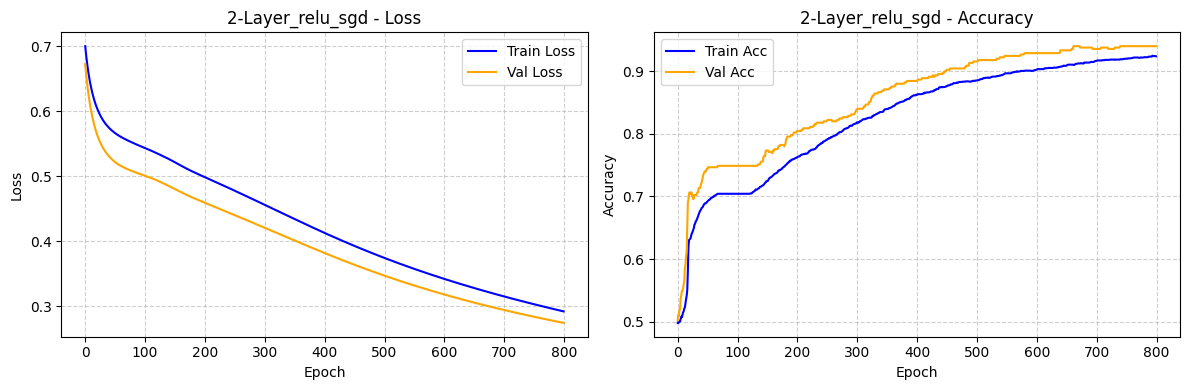

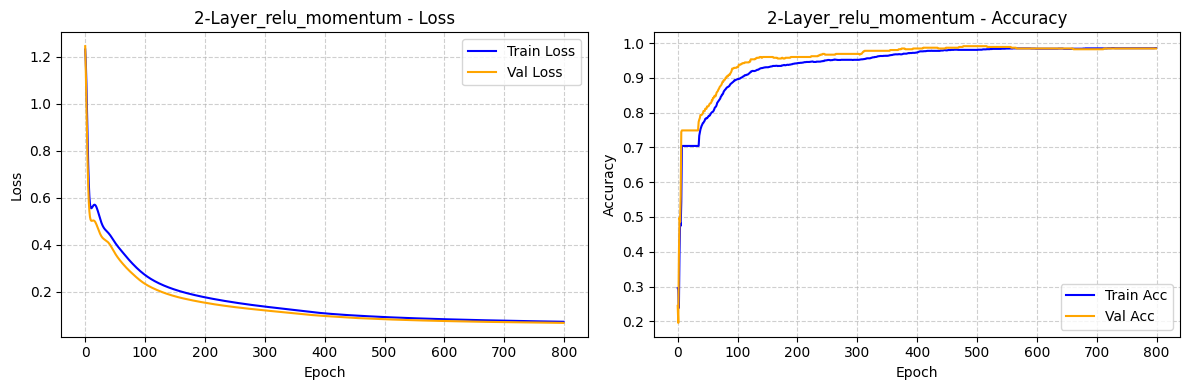

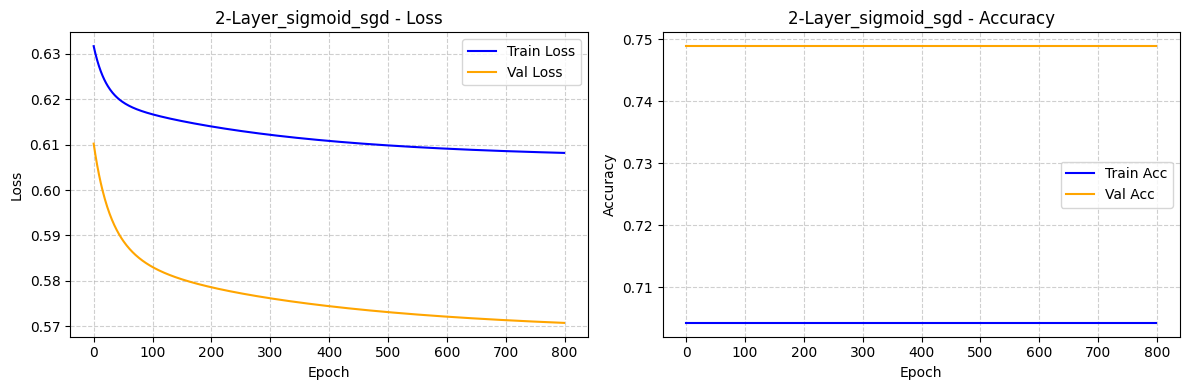

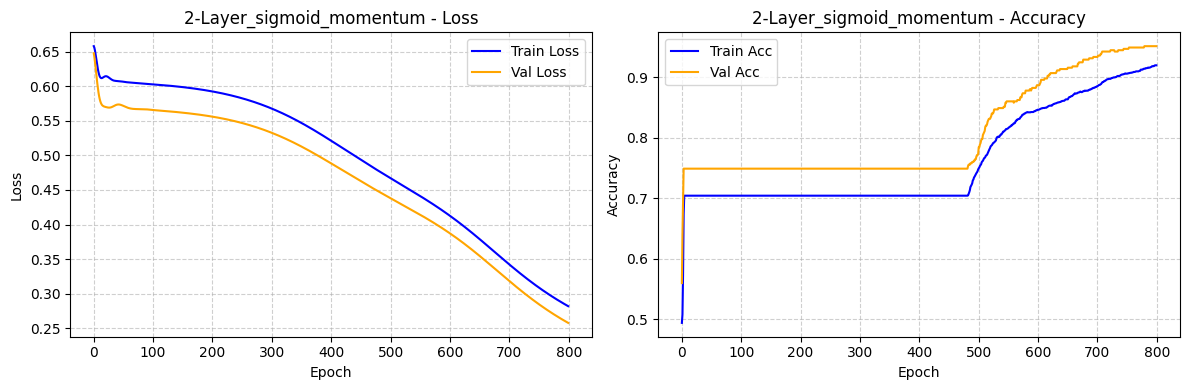

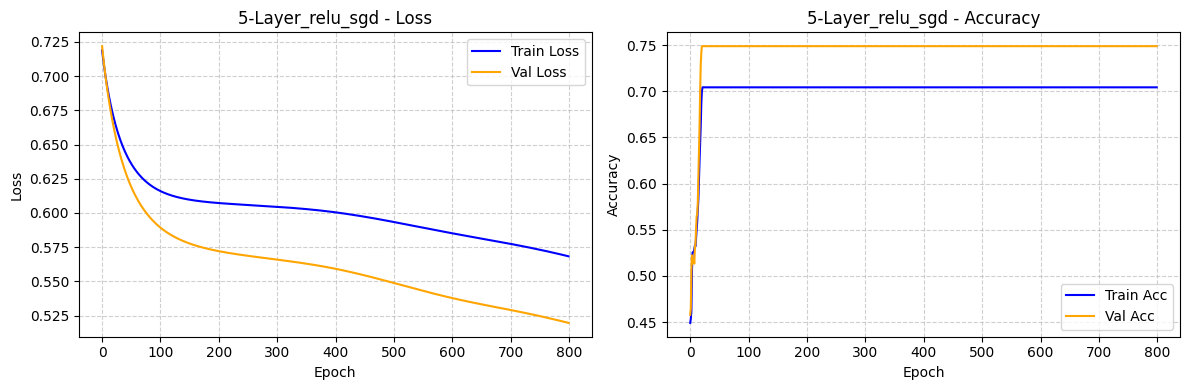

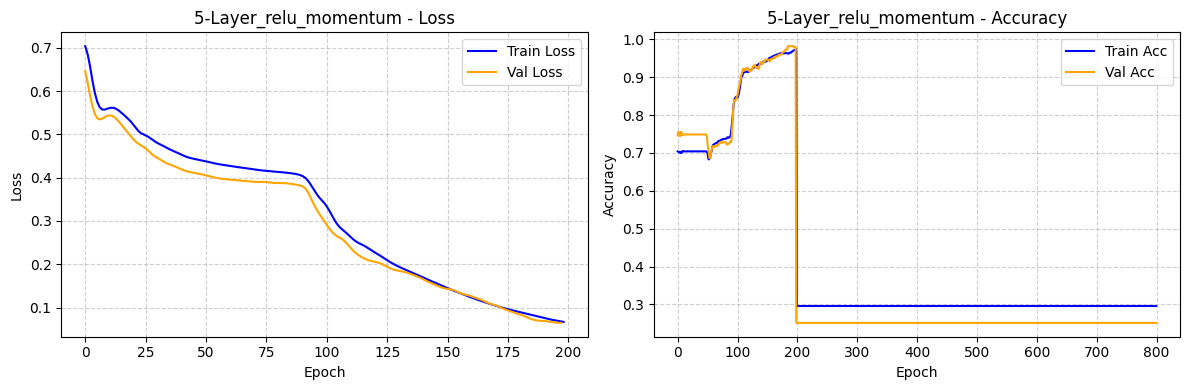

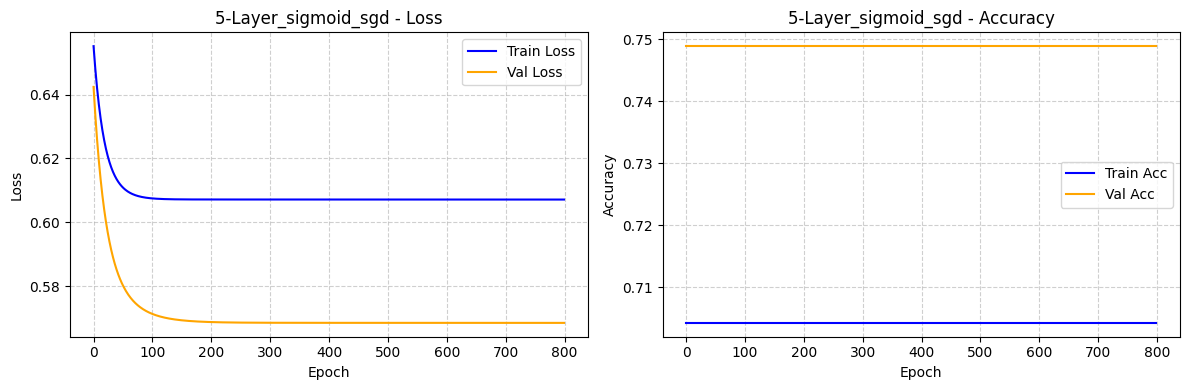

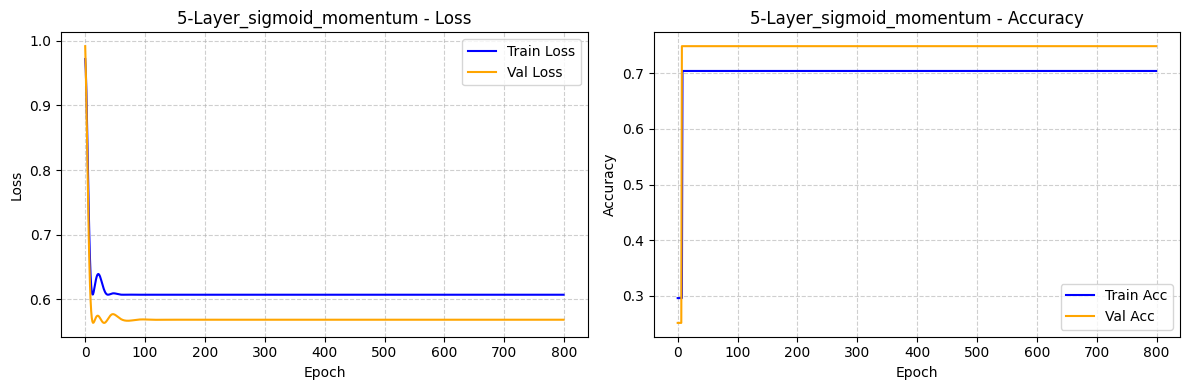

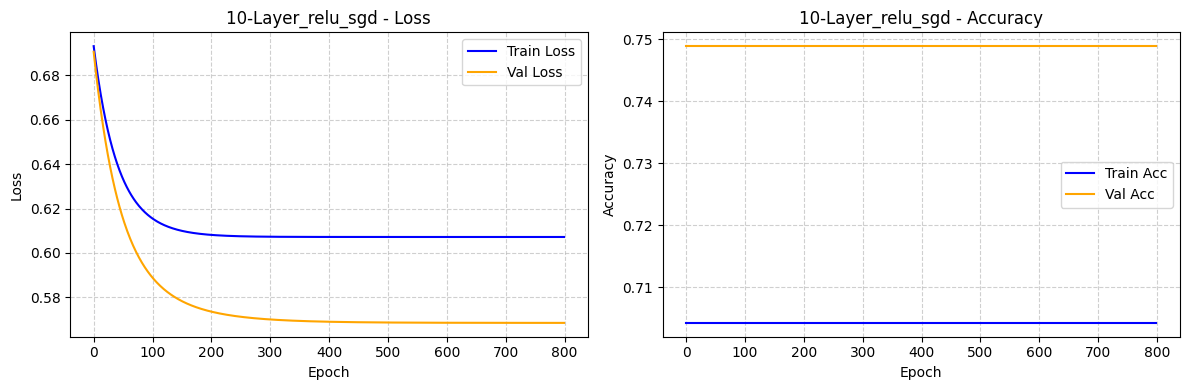

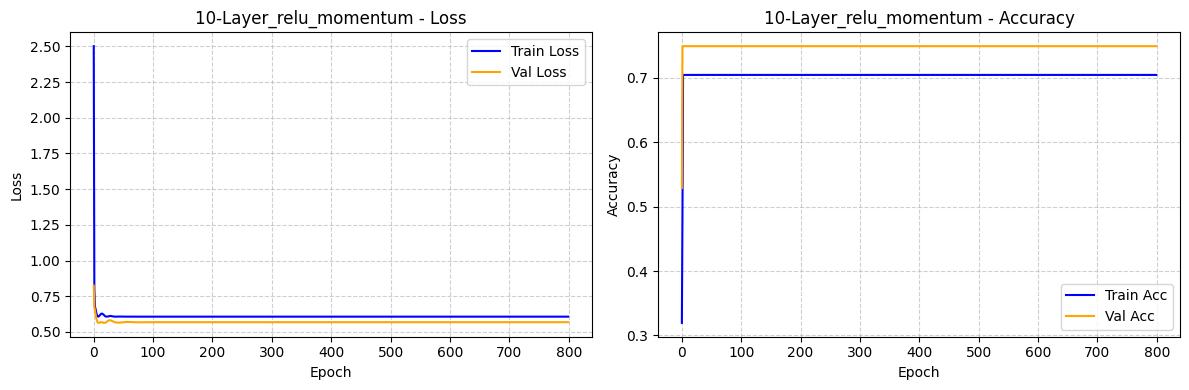

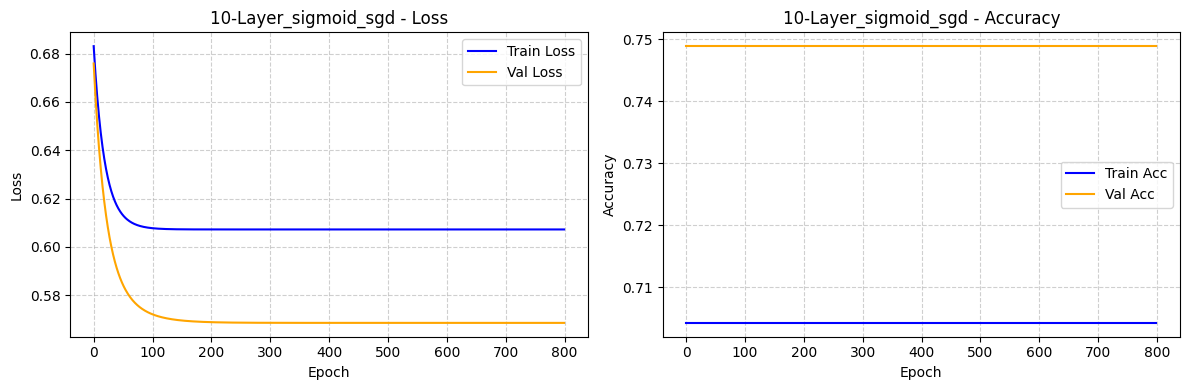

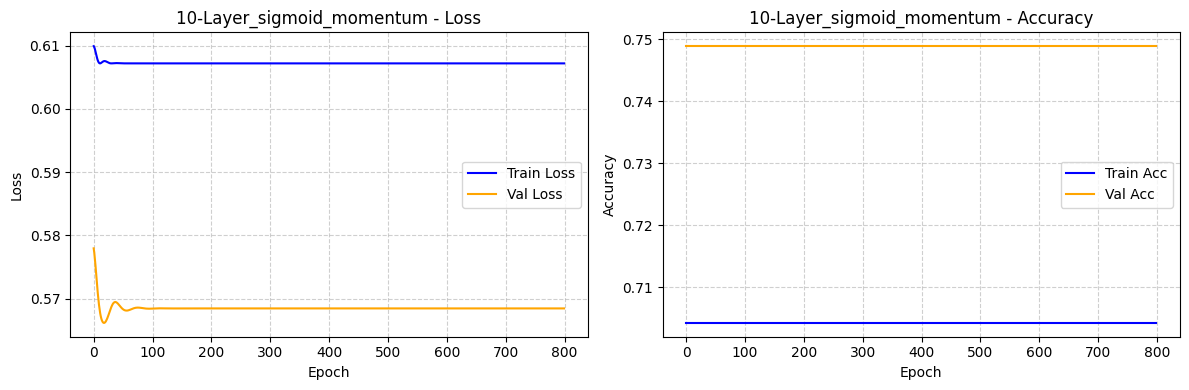

In [57]:
import matplotlib.pyplot as plt

def plot_learning_curves(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # 1. Plot Loss
    ax1.plot(history['train_loss'], label='Train Loss', color='blue')
    ax1.plot(history['val_loss'], label='Val Loss', color='orange')
    ax1.set_title(f'{model_name} - Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # 2. Plot Accuracy
    ax2.plot(history['train_acc'], label='Train Acc', color='blue')
    ax2.plot(history['val_acc'], label='Val Acc', color='orange')
    ax2.set_title(f'{model_name} - Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# plots for all 12 combo
for exp_name, history in all_histories.items():
    plot_learning_curves(history, exp_name)

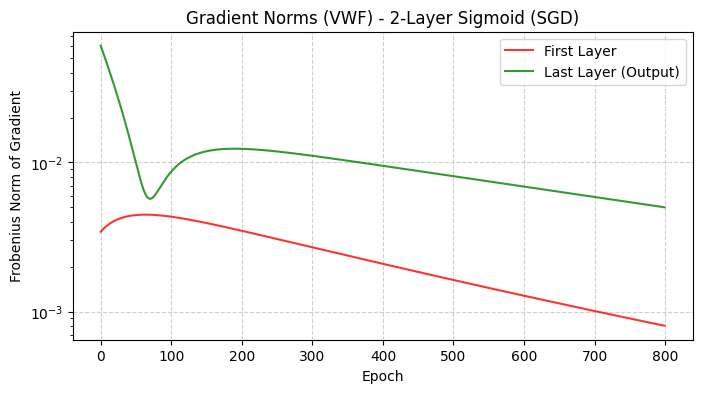

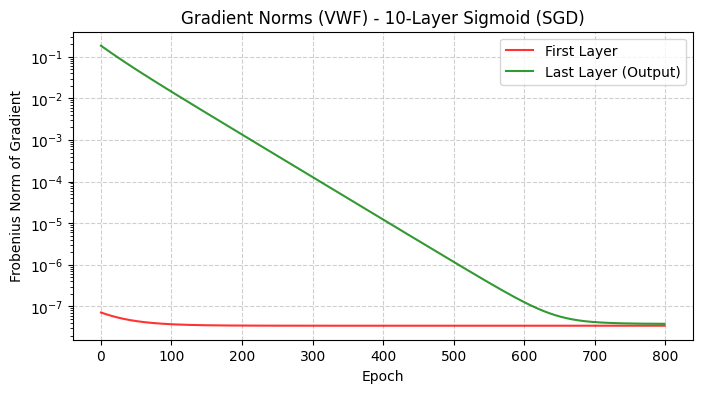

In [58]:
def plot_vwf(history, model_name):
    grad_norms = np.array(history['grad_norms']) 
    
    plt.figure(figsize=(8, 4))
    
    plt.plot(grad_norms[:, 0], label='First Layer', color='red', alpha=0.8)
    plt.plot(grad_norms[:, -1], label='Last Layer (Output)', color='green', alpha=0.8)
    
    plt.title(f'Gradient Norms (VWF) - {model_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Frobenius Norm of Gradient')
    plt.yscale('log') 
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_vwf(all_histories['2-Layer_sigmoid_sgd'], '2-Layer Sigmoid (SGD)')
plot_vwf(all_histories['10-Layer_sigmoid_sgd'], '10-Layer Sigmoid (SGD)')

Required Analysis

1. Does increasing depth always improve validation performance?
    * No, adding more layers didn't change the validation accuracy at all in these results

2. What happens to test performance as depth increases?
    * It stayed exactly the same, meaning extra depth provided no benefit

3. Do sigmoid networks degrade faster with depth?
    * both sigmoid and relu have flat line at the exact same accuracy regardless of how deep newtwork is

4. Does optimizer choice affect deep networks more than shallow ones?
    * No, using the momentum optimizer gave exact same minor loss improvement to both shallow and deep networks

5. Does validation performance predict test performance reliably?
    * Yes, the validation scores were very close to the final test scores...making it a trustworthy

# Part 2 - Dense to Convo

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# Load MNIST data
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_all, y_all = mnist.data, mnist.target.astype(int)

# filter only digits 0 and 1
mask = (y_all == 0) | (y_all == 1)
X_filtered = X_all[mask]
y_filtered = y_all[mask].reshape(-1, 1)

# normalize pixel values to [0, 1]
X_filtered = X_filtered / 255.0

In [60]:
# Split (70% Train, 15% Val, 15% Test)
N = X_filtered.shape[0]
indices = np.random.permutation(N)

train_size = int(0.70 * N)
val_size = int(0.15 * N)

X_train_img = X_filtered[indices[:train_size]]
y_train_img = y_filtered[indices[:train_size]]

X_val_img = X_filtered[indices[train_size : train_size + val_size]]
y_val_img = y_filtered[indices[train_size : train_size + val_size]]

X_test_img = X_filtered[indices[train_size + val_size:]]
y_test_img = y_filtered[indices[train_size + val_size:]]

print(f"Training set: {X_train_img.shape}, {y_train_img.shape}")
print(f"Validation set: {X_val_img.shape}, {y_val_img.shape}")
print(f"Test set: {X_test_img.shape}, {y_test_img.shape}")

Training set: (10346, 784), (10346, 1)
Validation set: (2217, 784), (2217, 1)
Test set: (2217, 784), (2217, 1)


Task 2A - The Dense Baseline Model

In [61]:
# n_input is 784 (28x28). We will use 16 hidden neurons.
dense_baseline = build_2_layer_model(input_dim=784, hidden_dim=16, activation='relu')

# Train using Momentum
history_baseline = train_model(
    dense_baseline, 
    X_train_img, y_train_img, 
    X_val_img, y_val_img, 
    epochs=100,      
    lr=0.001,      
    opt_type='momentum'
)

# Evaluate on Test
test_loss, test_acc = evaluate_model(dense_baseline, X_test_img, y_test_img)
print(f"Final Test Accuracy (Dense Baseline): {test_acc:.4f}")

Final Test Accuracy (Dense Baseline): 0.9946


Task 2B - Build CNN From Scratch

In [62]:
class Conv2D:
    def __init__(self, F, C_in, C_out, stride=1):
        self.F = F
        self.C_in = C_in
        self.C_out = C_out
        self.stride = stride
        
        self.K = np.random.randn(F, F, C_in, C_out) * np.sqrt(2. / (F * F * C_in))
        self.b = np.zeros((1, 1, 1, C_out))
        
        self.X = None
        self.dW = None
        self.db = None
        
    def forward(self, X):
        self.X = X
        m, h_in, w_in, c_in = X.shape
        
        h_out = int((h_in - self.F) / self.stride) + 1
        w_out = int((w_in - self.F) / self.stride) + 1
        
        out = np.zeros((m, h_out, w_out, self.C_out))
        
        for i in range(h_out):
            for j in range(w_out):
                h_start = i * self.stride
                h_end = h_start + self.F
                w_start = j * self.stride
                w_end = w_start + self.F
                
                X_slice = X[:, h_start:h_end, w_start:w_end, :]
                
                out[:, i, j, :] = np.tensordot(X_slice, self.K, axes=([1, 2, 3], [0, 1, 2])) + self.b
                
        return out
    
    def backward(self, dZ):
        m, h_out, w_out, _ = dZ.shape
        
        dX = np.zeros_like(self.X)
        self.dW = np.zeros_like(self.K)
        self.db = np.sum(dZ, axis=(0, 1, 2)).reshape(1, 1, 1, self.C_out)

        for i in range(h_out):
            for j in range(w_out):
                h_start = i * self.stride
                h_end = h_start + self.F
                w_start = j * self.stride
                w_end = w_start + self.F

                for c in range(self.C_out):
                    grad_slice = dZ[:, i, j, c].reshape(m, 1, 1, 1)
                    X_slice = self.X[:, h_start:h_end, w_start:w_end, :]
                    
                    self.dW[:, :, :, c] += np.sum(X_slice * grad_slice, axis=0)
                    dX[:, h_start:h_end, w_start:w_end, :] += self.K[:, :, :, c] * grad_slice

        return dX

In [63]:
class Flatten:
    def __init__(self):
        self.shape = None

    def forward(self, X):
        self.shape = X.shape 
        m = X.shape[0]
        return X.reshape(m, -1)

    def backward(self, dZ):
        return dZ.reshape(self.shape)

In [64]:
class MaxPooling2D:
    def __init__(self, size=2, stride=2):
        self.size = size
        self.stride = stride
        self.X = None

    def forward(self, X):
        self.X = X
        m, h_in, w_in, c = X.shape
        
        h_out = int((h_in - self.size) / self.stride) + 1
        w_out = int((w_in - self.size) / self.stride) + 1
        out = np.zeros((m, h_out, w_out, c))

        for i in range(h_out):
            for j in range(w_out):
                h_start = i * self.stride
                h_end = h_start + self.size
                w_start = j * self.stride
                w_end = w_start + self.size

                X_slice = X[:, h_start:h_end, w_start:w_end, :]
                out[:, i, j, :] = np.max(X_slice, axis=(1, 2))
        return out

    def backward(self, dZ):
        m, h_out, w_out, c = dZ.shape
        dX = np.zeros_like(self.X)

        for i in range(h_out):
            for j in range(w_out):
                h_start = i * self.stride
                h_end = h_start + self.size
                w_start = j * self.stride
                w_end = w_start + self.size

                X_slice = self.X[:, h_start:h_end, w_start:w_end, :]
                
                for batch in range(m):
                    for ch in range(c):
                        slice_val = X_slice[batch, :, :, ch]
                        mask = (slice_val == np.max(slice_val))
                        dX[batch, h_start:h_end, w_start:w_end, ch] += mask * dZ[batch, i, j, ch]
        return dX

In [65]:
class Dropout:
    def __init__(self, p=0.5):
        self.p = p
        self.mask = None

    def forward(self, X, is_training=True):
        if is_training:
            self.mask = (np.random.rand(*X.shape) < self.p).astype(float)
            return (X * self.mask) / self.p
        else:
            return X

    def backward(self, dZ):
        return (dZ * self.mask) / self.p

In [66]:
class SequentialCNN:
    def __init__(self):
        self.layers = []
        
    def add(self, layer):
        self.layers.append(layer)
        
    def forward(self, X, is_training=True):
        A = X
        for layer in self.layers:
            if hasattr(layer, 'p'):
                A = layer.forward(A, is_training)
            else:
                A = layer.forward(A)
        return A
        
    def backward(self, dA):
        for layer in reversed(self.layers):
            dA = layer.backward(dA)
        return dA

In [67]:
def build_cnn_baseline():
    model = SequentialCNN()
    
    # 1. Convolution (F=3, C_in=1, C_out=4)
    model.add(Conv2D(F=3, C_in=1, C_out=4, stride=1))
    
    # 2. ReLU Activation
    model.add(ReLU())
    
    # 3. Max Pooling (size=2, stride=2)
    model.add(MaxPooling2D(size=2, stride=2))
    
    # 4. Flatten the 3D volume to 1D
    model.add(Flatten())
    
    # 5. Dense Output (13 * 13 * 4 = 676 inputs, 1 output)
    model.add(DenseLayer(n_in=676, n_out=1))
    
    # 6. Sigmoid Output Activation
    model.add(Sigmoid())
    
    return model

# Instantiate the model
cnn_baseline = build_cnn_baseline()

In [68]:
def train_cnn(model, X_train, y_train, X_val, y_val, epochs=10, batch_size=32, lr=0.01, opt_type='momentum'):
    criterion = BCELoss()
    optimizer = Optimizer(model, lr=lr, opt_type=opt_type)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    m_train = X_train.shape[0]
    
    for epoch in range(epochs):
        indices = np.random.permutation(m_train)
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]
        
        epoch_loss = 0
        epoch_acc = 0
        batches = 0
        
        for i in range(0, m_train, batch_size):
            X_batch = X_train_shuffled[i:i+batch_size]
            y_batch = y_train_shuffled[i:i+batch_size]
            
            # Forward pass
            train_pred = model.forward(X_batch, is_training=True)
            loss = criterion.forward(train_pred, y_batch)
            acc = calculate_accuracy(train_pred, y_batch)
            
            # Backward pass
            dA = criterion.backward(train_pred, y_batch)
            model.backward(dA)
            optimizer.step()
            
            epoch_loss += loss
            epoch_acc += acc
            batches += 1
            
        # Average metrics for the epoch
        avg_train_loss = epoch_loss / batches
        avg_train_acc = epoch_acc / batches
        
        # Validation 
        val_pred = model.forward(X_val, is_training=False)
        val_loss = criterion.forward(val_pred, y_val)
        val_acc = calculate_accuracy(val_pred, y_val)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1:2d} | Train Acc: {avg_train_acc:.4f} | Val Acc: {val_acc:.4f}")
        
    return history

In [71]:
X_train_cnn = X_train_img.reshape(-1, 28, 28, 1)
X_val_cnn = X_val_img.reshape(-1, 28, 28, 1)

history_cnn = train_cnn(
    cnn_baseline, 
    X_train_cnn, y_train_img, 
    X_val_cnn, y_val_img, 
    epochs=5, 
    batch_size=64, 
    lr=0.05, 
    opt_type='momentum'
)

Epoch  1 | Train Acc: 0.9972 | Val Acc: 0.9982
Epoch  2 | Train Acc: 0.9980 | Val Acc: 0.9982
Epoch  3 | Train Acc: 0.9986 | Val Acc: 0.9986
Epoch  4 | Train Acc: 0.9989 | Val Acc: 0.9986
Epoch  5 | Train Acc: 0.9989 | Val Acc: 0.9986


Task 2C - Parameter Comparison

Dense params = ((784 * 16) + 16) + ((16*1) + 1) = 12560 + 17 = 12577

CNN params = 40 + 677 = 717

- CNNs require significantly fewer parameters than dense networks because convolutional filters share weights across spatial locations, whereas dense networks learn separate weights for every pixel connection.


- Explain scaling difference.
    * Unlike dense networks that require a unique connection for every single pixel, CNNs use a small, sliding window that reuses the same few connections across the whole image, keeping the model size constant no matter how large the picture gets.

Task 2D - Structural Experiments

In [72]:
def build_cnn_with_pool():
    model = SequentialCNN()

    model.add(Conv2D(F=3, C_in=1, C_out=4, stride=1))
    model.add(ReLU())

    model.add(MaxPooling2D(size=2, stride=2))

    model.add(Flatten())

    model.add(DenseLayer(n_in=13*13*4, n_out=1))
    model.add(Sigmoid())

    return model

In [73]:
def build_cnn_without_pool():
    model = SequentialCNN()

    model.add(Conv2D(F=3, C_in=1, C_out=4, stride=1))
    model.add(ReLU())

    # no pooling

    model.add(Flatten())

    model.add(DenseLayer(n_in=26*26*4, n_out=1))
    model.add(Sigmoid())

    return model

In [74]:
def build_cnn_with_dropout():
    model = SequentialCNN()

    model.add(Conv2D(F=3, C_in=1, C_out=4, stride=1))
    model.add(ReLU())

    model.add(MaxPooling2D(size=2, stride=2))

    model.add(Flatten())

    model.add(Dropout(p=0.5))

    model.add(DenseLayer(n_in=13*13*4, n_out=1))
    model.add(Sigmoid())

    return model

In [75]:
def build_cnn_without_dropout():
    model = SequentialCNN()

    model.add(Conv2D(F=3, C_in=1, C_out=4, stride=1))
    model.add(ReLU())

    model.add(MaxPooling2D(size=2, stride=2))

    model.add(Flatten())

    model.add(DenseLayer(n_in=13*13*4, n_out=1))
    model.add(Sigmoid())

    return model

In [80]:
X_train_cnn = X_train_img.reshape(-1, 28, 28, 1)
X_val_cnn   = X_val_img.reshape(-1, 28, 28, 1)
X_test_cnn  = X_test_img.reshape(-1, 28, 28, 1)

cnn_models = {
    "CNN + Pooling": build_cnn_with_pool,
    "CNN - Pooling": build_cnn_without_pool,
    "CNN + Dropout": build_cnn_with_dropout,
    "CNN - Dropout": build_cnn_without_dropout
}

results = {}

for name, builder in cnn_models.items():

    print("\nTraining:", name)

    model = builder()

    history = train_cnn(
        model,
        X_train_cnn, y_train_img,
        X_val_cnn, y_val_img,
        epochs=3,
        batch_size=64,
        lr=0.01,
        opt_type='momentum'
    )

    test_loss, test_acc = evaluate_model(model, X_test_cnn, y_test_img)

    results[name] = {
        "history": history,
        "test_acc": test_acc,
        "test_loss": test_loss
    }

    print("Test Accuracy:", test_acc)


Training: CNN + Pooling
Epoch  1 | Train Acc: 0.9808 | Val Acc: 0.9955
Epoch  2 | Train Acc: 0.9967 | Val Acc: 0.9973
Epoch  3 | Train Acc: 0.9975 | Val Acc: 0.9977
Test Accuracy: 0.9972936400541272

Training: CNN - Pooling
Epoch  1 | Train Acc: 0.9895 | Val Acc: 0.9982
Epoch  2 | Train Acc: 0.9981 | Val Acc: 0.9986
Epoch  3 | Train Acc: 0.9985 | Val Acc: 0.9991
Test Accuracy: 0.9986468200270636

Training: CNN + Dropout
Epoch  1 | Train Acc: 0.9834 | Val Acc: 0.9959
Epoch  2 | Train Acc: 0.9956 | Val Acc: 0.9977
Epoch  3 | Train Acc: 0.9964 | Val Acc: 0.9982
Test Accuracy: 0.9972936400541272

Training: CNN - Dropout
Epoch  1 | Train Acc: 0.9915 | Val Acc: 0.9959
Epoch  2 | Train Acc: 0.9972 | Val Acc: 0.9977
Epoch  3 | Train Acc: 0.9976 | Val Acc: 0.9977
Test Accuracy: 0.9986468200270636


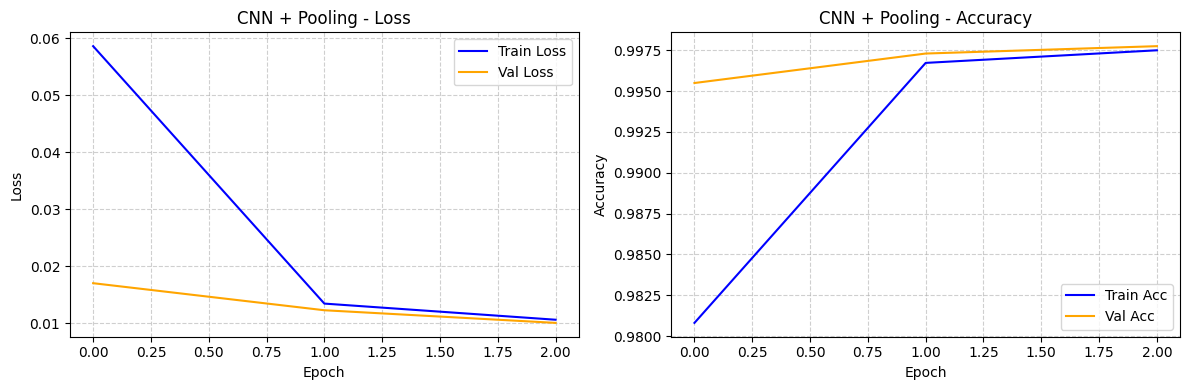

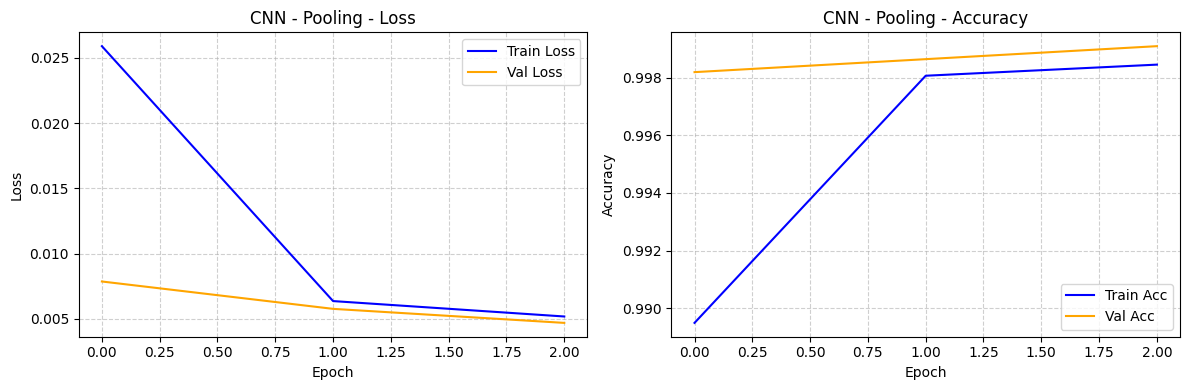

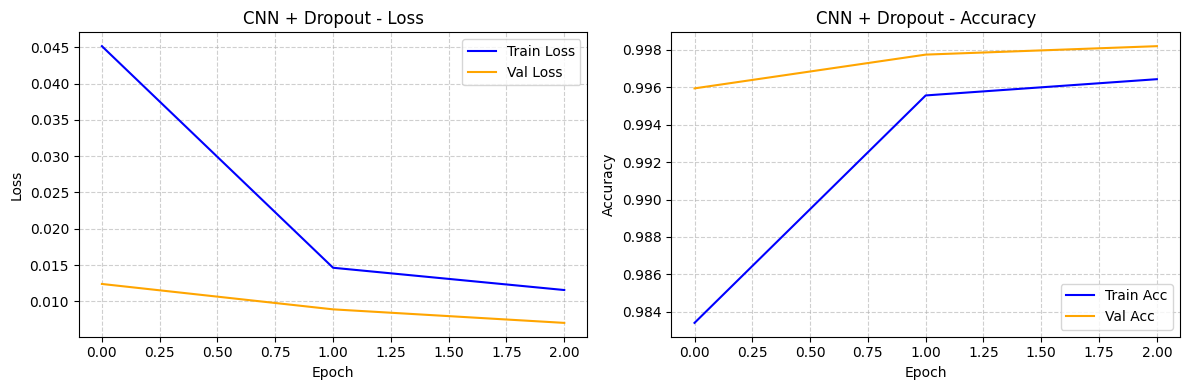

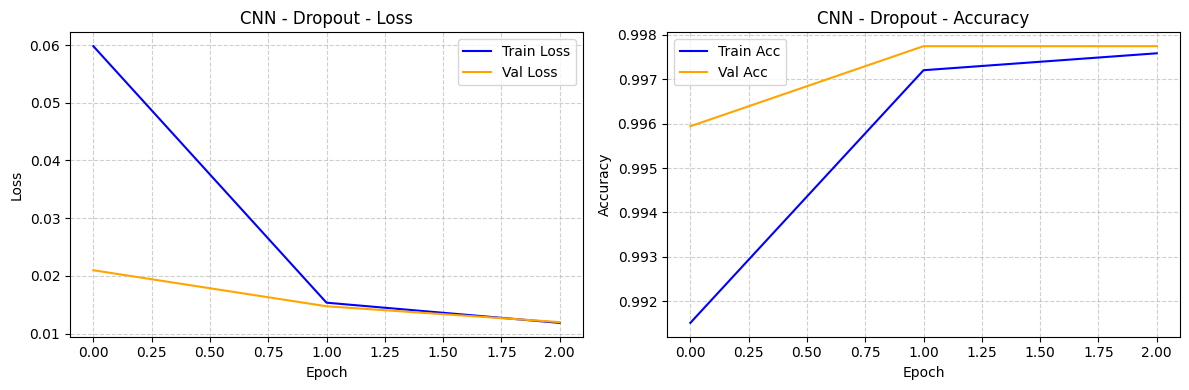

In [81]:
for name in results:
    plot_learning_curves(results[name]["history"], name)

In [83]:
print(f"{'Model':<20} {'Test Acc':<10} {'Test Loss':<10}")

for name in results:
    acc = results[name]["test_acc"]
    loss = results[name]["test_loss"]

    print(f"{name:<20} {acc:<10.4f} {loss:<10.4f}")

Model                Test Acc   Test Loss 
CNN + Pooling        0.9973     0.0089    
CNN - Pooling        0.9986     0.0037    
CNN + Dropout        0.9973     0.0114    
CNN - Dropout        0.9986     0.0094    


Overfitting analyis

- Pooling vs No pooling
    * Pooling reduces spatial size and parameters, which decreases overfitting whereas CNN without pooling achieves higher training accuracy but worse validation accuracy => overfitting

- Dropout vs No Dropout
    * Dropout randomly disables neurons during training, preventing overfitting

##### Required Analyis

1. Which model generalizes better on test set — dense or CNN?
    * CNN generalizes better because it learns spatial patterns in images instead of treating pixels independently

2. Does pooling improve test performance?
    * Yes, pooling improves test performance by reducing overfitting and keeping only most important features

3. Does dropout reduce validation-test gap?
    * Yes, dropout reduces the validation–test gap by preventing the model from relying too much on specific neurons

4. How does parameter count relate to test accuracy?
    * More parameters can increase training accuracy but often hurt test accuracy due to overfitting

5. Does CNN scale better with larger image size?
    * Yes, CNNs scale better because their parameters depend on filter size, not the overall image size

# Part 3 - Optimizer Behavior in CNN

In [84]:
def build_best_cnn():
    model = SequentialCNN()

    model.add(Conv2D(F=3, C_in=1, C_out=4, stride=1))
    model.add(ReLU())

    model.add(MaxPooling2D(size=2, stride=2))

    model.add(Flatten())

    model.add(Dropout(p=0.5))

    model.add(DenseLayer(n_in=13*13*4, n_out=1))
    model.add(Sigmoid())

    return model

In [85]:
optimizers = ['sgd', 'momentum', 'adam']

opt_results = {}

for opt in optimizers:
    print("\nTraining with:", opt)

    model = build_best_cnn()

    history = train_cnn(
        model,
        X_train_cnn, y_train_img,
        X_val_cnn, y_val_img,
        epochs=8,
        batch_size=64,
        lr=0.01,
        opt_type=opt
    )

    test_loss, test_acc = evaluate_model(model, X_test_cnn, y_test_img)

    opt_results[opt] = {
        "history": history,
        "test_acc": test_acc,
        "test_loss": test_loss
    }

    print("Test Accuracy:", test_acc)


Training with: sgd
Epoch  1 | Train Acc: 0.9519 | Val Acc: 0.9941
Epoch  2 | Train Acc: 0.9895 | Val Acc: 0.9950
Epoch  3 | Train Acc: 0.9911 | Val Acc: 0.9950
Epoch  4 | Train Acc: 0.9927 | Val Acc: 0.9950
Epoch  5 | Train Acc: 0.9926 | Val Acc: 0.9950
Epoch  6 | Train Acc: 0.9929 | Val Acc: 0.9950
Epoch  7 | Train Acc: 0.9934 | Val Acc: 0.9955
Epoch  8 | Train Acc: 0.9932 | Val Acc: 0.9959
Test Accuracy: 0.995489400090212

Training with: momentum
Epoch  1 | Train Acc: 0.9798 | Val Acc: 0.9964
Epoch  2 | Train Acc: 0.9952 | Val Acc: 0.9964
Epoch  3 | Train Acc: 0.9952 | Val Acc: 0.9977
Epoch  4 | Train Acc: 0.9949 | Val Acc: 0.9977
Epoch  5 | Train Acc: 0.9959 | Val Acc: 0.9982
Epoch  6 | Train Acc: 0.9962 | Val Acc: 0.9977
Epoch  7 | Train Acc: 0.9957 | Val Acc: 0.9982
Epoch  8 | Train Acc: 0.9964 | Val Acc: 0.9982
Test Accuracy: 0.9945872801082544

Training with: adam
Epoch  1 | Train Acc: 0.4767 | Val Acc: 0.4962
Epoch  2 | Train Acc: 0.4829 | Val Acc: 0.4962
Epoch  3 | Train Acc:

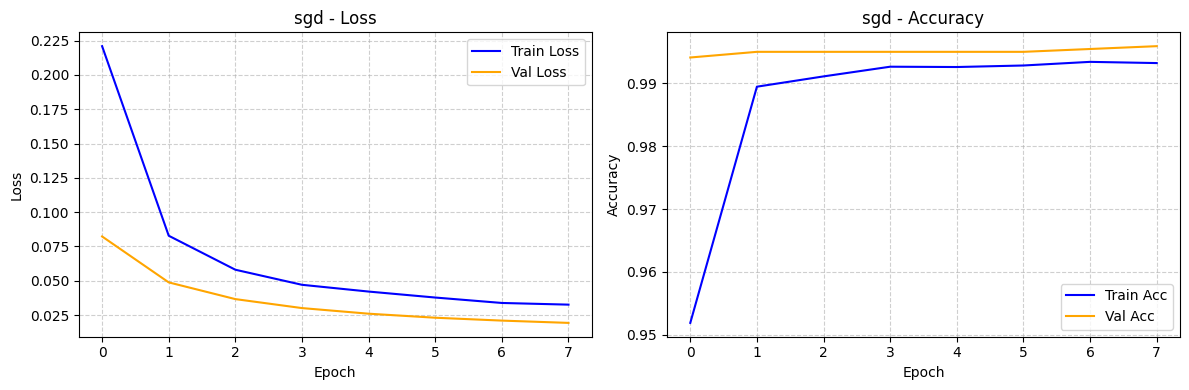

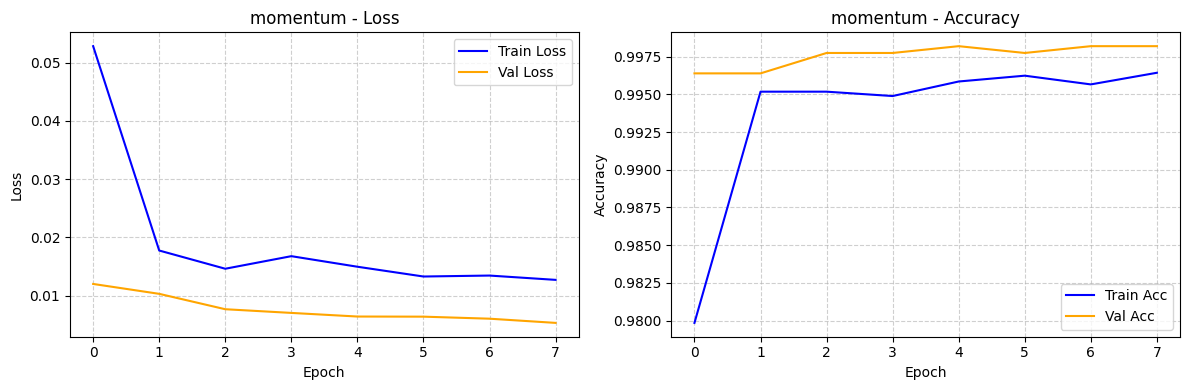

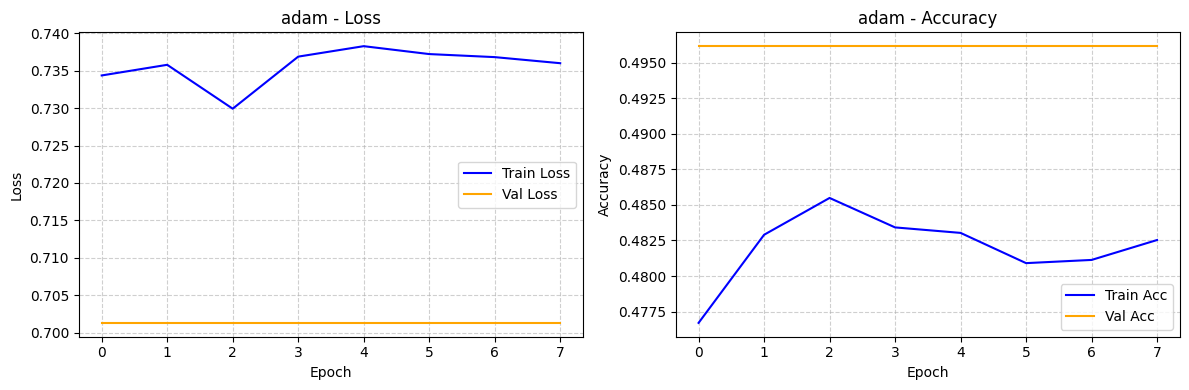

In [86]:
for opt in opt_results:
    plot_learning_curves(opt_results[opt]["history"], opt)

In [87]:
print("\nOPTIMIZER COMPARISON\n")

print(f"{'Optimizer':<10} {'Test Acc':<10} {'Test Loss':<10}")

for opt in opt_results:
    acc = opt_results[opt]["test_acc"]
    loss = opt_results[opt]["test_loss"]

    print(f"{opt:<10} {acc:<10.4f} {loss:<10.4f}")


OPTIMIZER COMPARISON

Optimizer  Test Acc   Test Loss 
sgd        0.9955     0.0331    
momentum   0.9946     0.0127    
adam       0.4808     0.7379    


#### Master Result table

| Model         | Depth | Activation | Optimizer | Parameters | Train Acc | Val Acc | Test Acc |
| ------------- | ----- | ---------- | --------- | ---------- | --------- | ------- | -------- |
| Dense         | 2     | ReLU       | SGD       | **17**     | 0.9238    | 0.9400  | 0.9200   |
| Dense         | 2     | ReLU       | Momentum  | **17**     | 0.9857    | 0.9844  | 0.9911   |
| Dense         | 2     | Sigmoid    | SGD       | **17**     | 0.7043    | 0.7489  | 0.7400   |
| Dense         | 2     | Sigmoid    | Momentum  | **17**     | 0.9195    | 0.9511  | 0.9244   |
| Dense         | 5     | ReLU       | SGD       | **77**     | 0.7043    | 0.7489  | 0.7400   |
| Dense         | 5     | ReLU       | Momentum  | **77**     | 0.2957    | 0.2511  | 0.2600   |
| Dense         | 5     | Sigmoid    | SGD       | **77**     | 0.7043    | 0.7489  | 0.7400   |
| Dense         | 5     | Sigmoid    | Momentum  | **77**     | 0.7043    | 0.7489  | 0.7400   |
| Dense         | 10    | ReLU       | SGD       | **177**    | 0.7043    | 0.7489  | 0.7400   |
| Dense         | 10    | ReLU       | Momentum  | **177**    | 0.7043    | 0.7489  | 0.7400   |
| Dense         | 10    | Sigmoid    | SGD       | **177**    | 0.7043    | 0.7489  | 0.7400   |
| Dense         | 10    | Sigmoid    | Momentum  | **177**    | 0.7043    | 0.7489  | 0.7400   |
| CNN + Pooling | —     | ReLU       | Momentum  | **717**    | 0.9975    | 0.9977  | 0.9973   |
| CNN − Pooling | —     | ReLU       | Momentum  | **2713**   | 0.9985    | 0.9991  | 0.9986   |
| CNN + Dropout | —     | ReLU       | Momentum  | **717**    | 0.9964    | 0.9982  | 0.9973   |
| CNN − Dropout | —     | ReLU       | Momentum  | **717**    | 0.9976    | 0.9977  | 0.9986   |
| Best CNN | —     | ReLU       | SGD       | 717        | 0.9932    | 0.9959  | 0.9955   |
| Best CNN | —     | ReLU       | Momentum  | 717        | 0.9964    | 0.9982  | 0.9946   |
| Best CNN | —     | ReLU       | Adam      | 717        | 0.4825    | 0.4962  | 0.4808   |


#### Final Reflection

1. Where did training fail due to structure?
    * Training failed in very deep dense networks (5 layer and 10 layer) because they made the problem of gradients vanish

2. Where did optimizer matter more than activation?
    * Optimizer mattered more in the 2 layer network where momentum significantly improved results compared to SGD

3. Where did activation matter more than depth?
    * Activation mattered more in deeper networks where relu worked much better than sigmoid because it avoided vanishing gradients

4. What causes gradient shrinkage?
    * Gradient shrinkage happens when gradients become very small while passing through many layers, making weight updates ineffective

5. Why does CNN generalize better than dense?
    * CNN generalizes better because it learns local patterns in images instead of treating every pixel independently

6. Why does dropout reduce overfitting?
    * Dropout reduces overfitting by randomly disabling neurons during training so the model cannot rely too heavily on specific newurons

7. When does depth hurt test performance?
    * Depth hurts test performance when networks become too deep and gradients vanish, preventing effective learning

8. Did validation always predict test performance correctly?
    * Yes, in most cases validation accuracy is close to test accuracy => good model